<a href="https://colab.research.google.com/github/ERA-Software/computational-data-analysis/blob/w7_bb/notebooks/S7_bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Bias-Variance Trade-Off and Model Selection

**Lecture 7. Computational Data Analysis with Python**

---

This notebook is self-contained. It covers the following blocks:

1. **Generalization vs. Training Performance**: why training error is not the goal
2. **The Bias-Variance Decomposition**: the fundamental equation of supervised learning
3. **Underfitting vs. Overfitting**: diagnosing which problem you have
4. **Train / Validation / Test Split**: why you need three datasets, not two
5. **Cross-Validation**: $K$-fold, LOOCV, and structured variants
6. **Hyperparameter Tuning**: grid search, random search
7. **Regularization**: Ridge, Lasso, and the Bayesian interpretation

**Running examples:**
- Blocks 1–3: synthetic cubic DGP — $f(x) = 5 + 2x - 0.5x^2 + 0.1x^3$, $\sigma = 1.5$
- Blocks 4–7: UCI Bike Sharing dataset ($n \approx 17{,}000$, $p = 12$)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as norm_dist
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold, TimeSeriesSplit, cross_val_score, train_test_split
)
from sklearn.pipeline import make_pipeline

plt.rcParams.update({
    'figure.dpi': 140,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})

SEED = 42
rng  = np.random.RandomState(SEED)
BLUE, RED, GREEN, GRAY, ORANGE = '#1e5aa8', '#e04040', '#2ca02c', '#888888', '#ff7f0e'

print('All imports OK.')

All imports OK.


---
## Block 1 · Generalization vs. Training Performance

### The fundamental goal: predicting unseen data

Assume data are drawn i.i.d. from a joint distribution $P(X, Y)$. We train a model $\hat{f}$ on a dataset $D_{\text{train}} = \{(x_i, y_i)\}_{i=1}^n$.

**Training error**:
$$\hat{R}_{\text{train}}(\hat{f}) = \frac{1}{n}\sum_{i=1}^n \ell(\hat{f}(x_i),\, y_i)$$

**Generalization error** (unseen data):
$$R(\hat{f}) = \mathbb{E}_{(x,y)\sim P}[\ell(\hat{f}(x),\, y)]$$

The **generalization gap** $R(\hat{f}) - \hat{R}_{\text{train}}(\hat{f})$ measures how much worse the model does on unseen data compared to training data. A large gap means the model has memorized training noise rather than learned the underlying pattern.

> **Analogy.** A student who memorizes past exam answers scores perfectly on practice tests but fails the real exam. The real exam draws from the same distribution of problems, but different instances. Understanding the principles (generalizing) beats memorization (overfitting), even if practice scores are lower.

### Synthetic data-generating process

The true function is a cubic polynomial:
$$f(x) = 5 + 2x - 0.5x^2 + 0.1x^3, \qquad x \sim \text{Uniform}(-3, 3), \qquad \epsilon \sim N(0, \sigma^2), \quad \sigma = 1.5$$

We observe $y = f(x) + \epsilon$. Because we generated the data, we know the true function, which lets us compute the exact bias-variance decomposition later.

We use a **degree $d$ polynomial** as our hypothesis class throughout Blocks 1–3. The "complexity dial" is $d$:
- $d = 1$: linear model, almost certainly too simple (high bias)
- $d = 3$: matches the true structure (the sweet spot)
- $d = 15$ or $20$: far more flexible than needed (high variance)

In [19]:
# --- True DGP ---
def f_true(x):
    return 5 + 2*x - 0.5*x**2 + 0.1*x**3

SIGMA = 1.5  # noise standard deviation

def generate_data(n, seed):
    rng_loc = np.random.RandomState(seed)
    x = rng_loc.uniform(-3, 3, n)
    y = f_true(x) + rng_loc.normal(0, SIGMA, n)
    return x, y

# Fixed training and test sets for Block 1
n_train_s, n_test_s = 80, 500
x_tr_s, y_tr_s = generate_data(n_train_s, seed=SEED)
x_te_s, y_te_s = generate_data(n_test_s,  seed=99)
x_plot = np.linspace(-3.2, 3.2, 500)

print(f'Training set : n = {n_train_s}')
print(f'Test set     : n = {n_test_s}')
print(f'Noise sigma  : {SIGMA}')
print(f'Noise floor  : sigma^2 = {SIGMA**2:.2f}')
print(f'True function: f(x) = 5 + 2x - 0.5x^2 + 0.1x^3')

Training set : n = 80
Test set     : n = 500
Noise sigma  : 1.5
Noise floor  : sigma^2 = 2.25
True function: f(x) = 5 + 2x - 0.5x^2 + 0.1x^3


### Exercise 1: Training MSE vs. Test MSE as a function of polynomial degree

Fit polynomial regressions of degree $d \in \{1, 2, 3, 5, 7, 10, 15, 20\}$ on the training set. Compute training MSE and test MSE for each. **Expected behavior:**
- Training MSE decreases monotonically: a more flexible model can always fit training data better.
- Test MSE reaches a minimum near $d = 3$ (the true degree), then rises as the model starts memorizing noise.
- The noise floor $\sigma^2 = 2.25$ is a lower bound no model can beat.

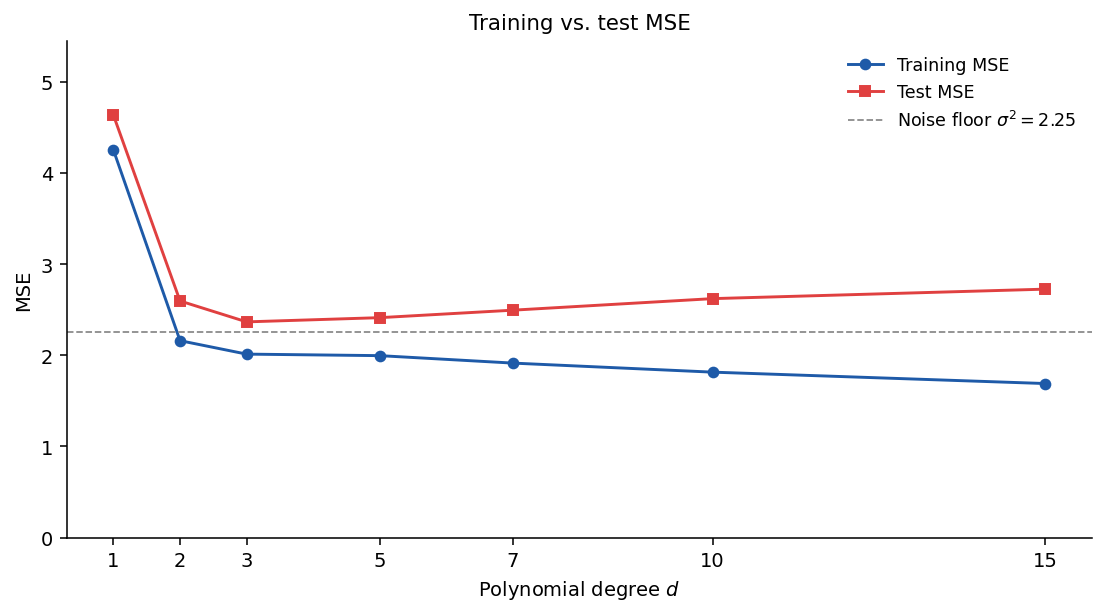

 Degree   Train MSE    Test MSE
---------------------------------
      1       4.248       4.631
      2       2.159       2.595
      3       2.012       2.366  <-- best test
      5       1.995       2.412
      7       1.914       2.494
     10       1.814       2.620
     15       1.689       2.724


In [20]:
degrees = [1, 2, 3, 5, 7, 10, 15]
train_mses, test_mses = [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    model.fit(x_tr_s.reshape(-1, 1), y_tr_s)
    train_mses.append(mean_squared_error(y_tr_s,  model.predict(x_tr_s.reshape(-1, 1))))
    test_mses.append( mean_squared_error(y_te_s,  model.predict(x_te_s.reshape(-1, 1))))

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(degrees, train_mses, 'o-', color=BLUE, label='Training MSE', markersize=5)
ax.plot(degrees, test_mses,  's-', color=RED,  label='Test MSE',     markersize=5)
ax.axhline(SIGMA**2, color=GRAY, linestyle='--', linewidth=0.9,
           label=f'Noise floor $\\sigma^2 = {SIGMA**2:.2f}$')
ax.set_xlabel('Polynomial degree $d$')
ax.set_ylabel('MSE')
ax.set_title('Training vs. test MSE')
ax.legend(frameon=False, fontsize=9)
ax.set_xticks(degrees)
ax.set_ylim(0, min(test_mses[0], test_mses[-1]) * 2.0)
plt.tight_layout()
plt.show()

print('%7s  %10s  %10s' % ('Degree', 'Train MSE', 'Test MSE'))
print('-' * 33)
for d, tr, te in zip(degrees, train_mses, test_mses):
    mark = '  <-- best test' if te == min(test_mses) else ''
    print(f'{d:>7}  {tr:>10.3f}  {te:>10.3f}{mark}')

**Interpretation.** Training MSE never increases with $d$: adding more parameters always allows the model to fit the training points more tightly. At $d = n$ the polynomial can pass through every training point exactly (interpolation), driving training MSE to zero.

Test MSE, however, follows a U-shape. The minimum is at $d = 3$; the model degree that matches the true data-generating function. For $d > 3$, the model fits the training noise, and predictions on new points deteriorate.

> **Key question:** Why does training MSE never exceed test MSE here? Can you construct a case where it does? (Hint: think about a very small training set with noisy labels.)

---
## Block 2 · The Bias-Variance Decomposition

### Setup

Assume the data-generating process:
$$y = f(x) + \epsilon, \qquad \mathbb{E}[\epsilon] = 0, \qquad \text{Var}(\epsilon) = \sigma^2.$$

We train $\hat{f}$ on a sample $D$ drawn from $P$. Since $D$ is random, $\hat{f} = \hat{f}_D$ is also a random variable, different training sets produce different fitted models.

The **expected prediction error** (EPE) at a fixed point $x_0$ decomposes as:

$$\boxed{\text{EPE}(x_0) = \sigma^2 + \left(\mathbb{E}_D[\hat{f}_D(x_0)] - f(x_0)\right)^2 + \text{Var}_D(\hat{f}_D(x_0))}$$


### The three terms

| Term | Meaning | Reducible? |
|---|---|---|
| $\sigma^2$ | Irreducible noise in the data — the floor. No model can beat it. | **No** |
| $\text{Bias}^2$ | How far the *average* prediction is from the truth. A too-simple model (a line through a curve) has high bias. It systematically misses, regardless of which training set you use. | Yes: increase complexity |
| $\text{Variance}$ | How much the prediction changes across training sets. A too-complex model (degree-20 polynomial) has high variance. It swings wildly depending on which noisy points ended up in the sample. | Yes: decrease complexity |

### The trade-off

As model complexity increases:
- **Bias decreases**: the model can represent more functions, so it approaches $f$.
- **Variance increases**: more parameters to estimate from the same $n$, so the fit becomes more sensitive to the particular training set.
- **$\sigma^2$ is constant**: it is a property of the problem, not the model.

The total EPE follows a U-shape. The optimal complexity $d^*$ minimizes EPE by balancing bias and variance.

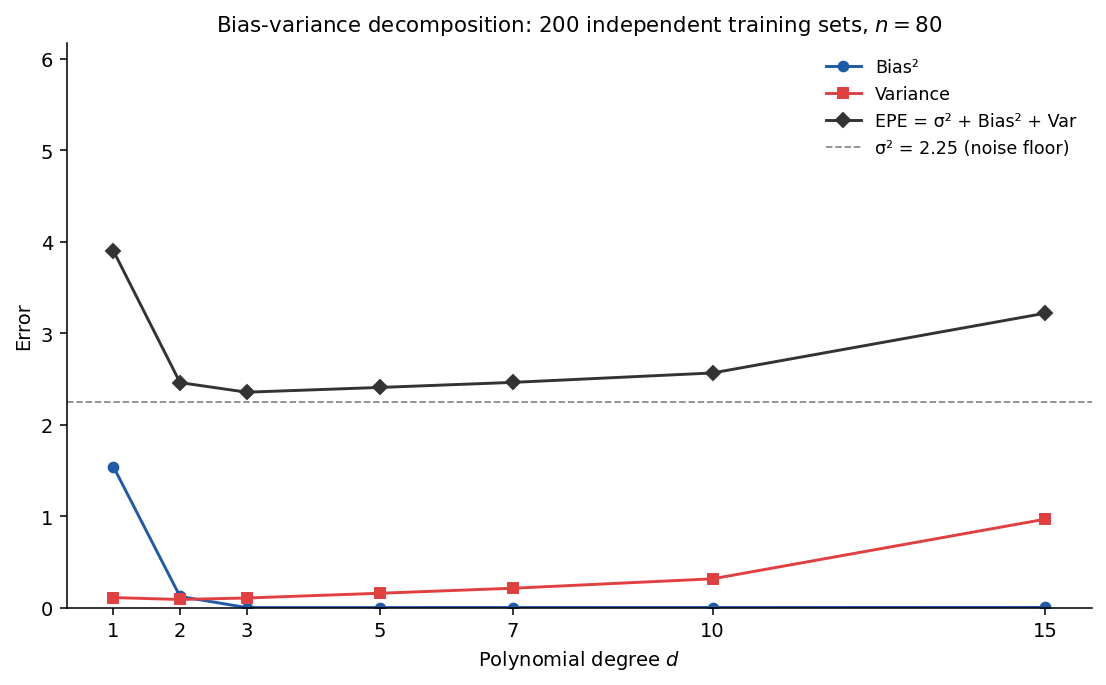

   d     Bias²       Var       EPE
------------------------------------
   1     1.539     0.110     3.899
   2     0.122     0.089     2.461
   3     0.000     0.105     2.356
   5     0.001     0.157     2.408
   7     0.001     0.212     2.463
  10     0.001     0.315     2.566
  15     0.002     0.967     3.220


In [21]:
# --- Exact bias-variance decomposition via simulation ---
# Draw N_SIMS independent training sets; for each degree, compute
# the mean and variance of predictions across training sets.

N_SIMS = 200
x_eval = np.linspace(-2.8, 2.8, 200)
f_eval = f_true(x_eval)

degrees_bv = [1, 2, 3, 5, 7, 10, 15]
bias2_list, var_list, epe_list = [], [], []

for d in degrees_bv:
    preds = np.zeros((N_SIMS, len(x_eval)))
    for s in range(N_SIMS):
        x_tr, y_tr = generate_data(n_train_s, seed=s)
        m = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
        m.fit(x_tr.reshape(-1, 1), y_tr)
        preds[s] = m.predict(x_eval.reshape(-1, 1))
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - f_eval)**2)
    variance = np.mean(preds.var(axis=0))
    epe = SIGMA**2 + bias2 + variance
    bias2_list.append(bias2)
    var_list.append(variance)
    epe_list.append(epe)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees_bv, bias2_list,  'o-', color=BLUE,   label='Bias²',                markersize=5)
ax.plot(degrees_bv, var_list,    's-', color=RED,    label='Variance',              markersize=5)
ax.plot(degrees_bv, epe_list,    'D-', color='#333', label='EPE = σ² + Bias² + Var', markersize=5)
ax.axhline(SIGMA**2, color=GRAY, linestyle='--', linewidth=0.9, label=f'σ² = {SIGMA**2:.2f} (noise floor)')
ax.set_xlabel('Polynomial degree $d$')
ax.set_ylabel('Error')
ax.set_title(f'Bias-variance decomposition: {N_SIMS} independent training sets, $n={n_train_s}$')
ax.legend(frameon=False, fontsize=9)
ax.set_xticks(degrees_bv)
ax.set_ylim(0, np.percentile(epe_list, 80) * 2)
plt.tight_layout()
plt.show()

print('%4s  %8s  %8s  %8s' % ('d', 'Bias²', 'Var', 'EPE'))
print('-' * 36)
for d, b, v, e in zip(degrees_bv, bias2_list, var_list, epe_list):
    print(f'{d:>4}  {b:>8.3f}  {v:>8.3f}  {e:>8.3f}')

**What to observe:**
- Bias² is large for small $d$ and shrinks toward zero as $d \geq 3$ (the true degree).
- Variance grows sharply once $d > 5$. The model starts fitting the particular noise pattern of each training set.
- The EPE curve has a clear minimum near $d = 3$, confirming the U-shape.
- The EPE never drops below $\sigma^2 = 2.25$.

Now let's visualize *why* bias and variance behave this way by overlaying 20 fitted curves from 20 different training sets.

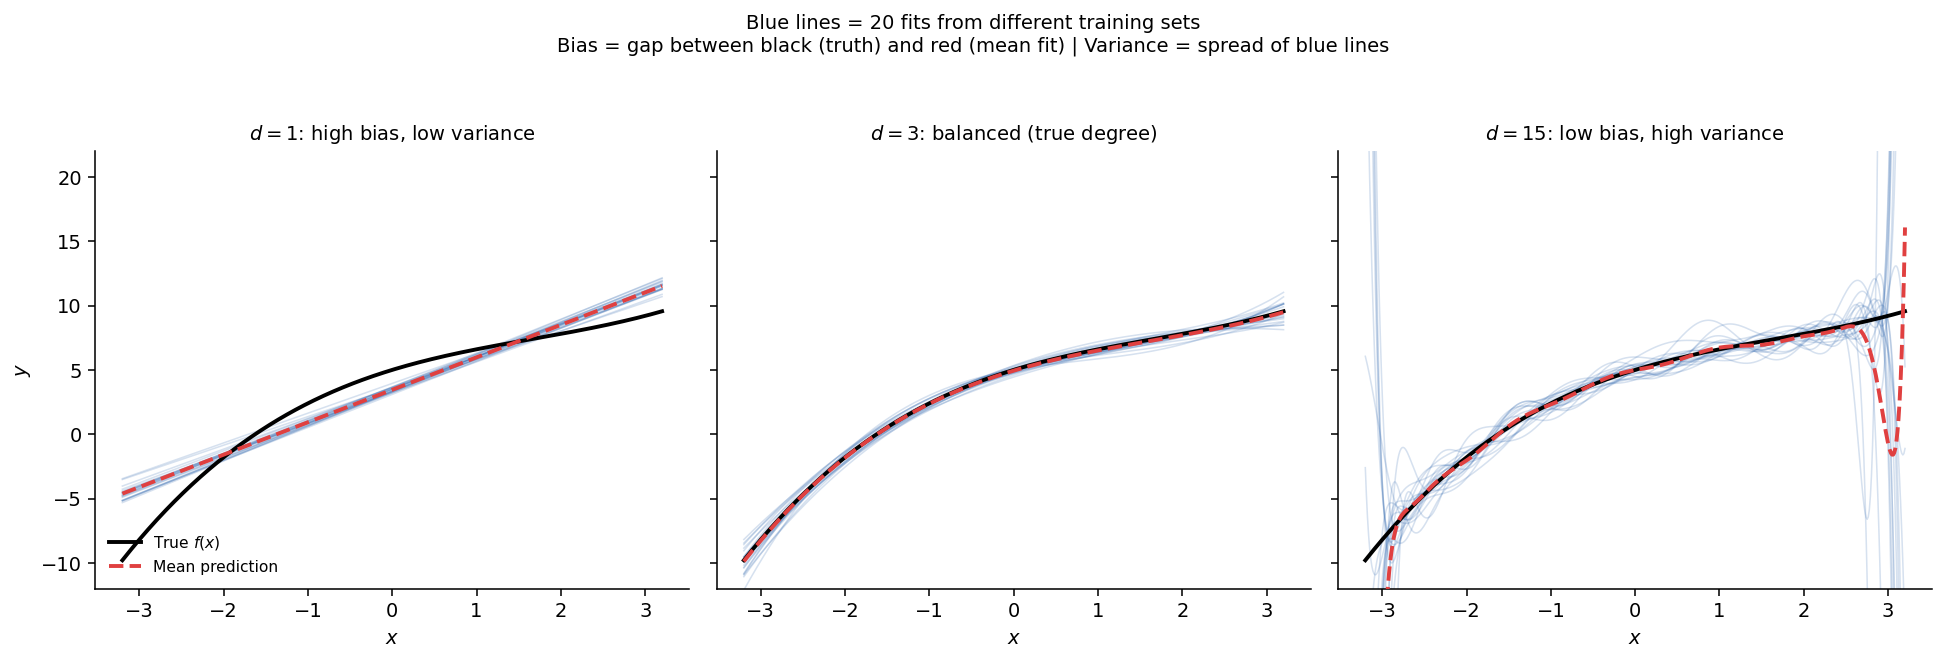

In [22]:
# --- Visualize multiple fits: bias = gap between truth and mean prediction;
#     variance = spread of blue curves ---

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
demo_degrees = [1, 3, 15]
titles = ['$d=1$: high bias, low variance',
          '$d=3$: balanced (true degree)',
          '$d=15$: low bias, high variance']

for ax, d, title in zip(axes, demo_degrees, titles):
    preds20 = np.zeros((20, len(x_plot)))
    for s in range(20):
        x_tr, y_tr = generate_data(n_train_s, seed=s + 1000)
        m = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
        m.fit(x_tr.reshape(-1, 1), y_tr)
        preds20[s] = m.predict(x_plot.reshape(-1, 1))
        ax.plot(x_plot, preds20[s], color=BLUE, alpha=0.18, linewidth=0.8)

    ax.plot(x_plot, f_true(x_plot),   color='black', linewidth=2.0,
            label='True $f(x)$', zorder=5)
    ax.plot(x_plot, preds20.mean(0),  color=RED, linewidth=2.0,
            linestyle='--', label='Mean prediction', zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x$')
    ax.set_ylim(-12, 22)
    if ax is axes[0]:
        ax.set_ylabel('$y$')
        ax.legend(frameon=False, fontsize=8, loc='lower left')

fig.suptitle(
    'Blue lines = 20 fits from different training sets\n'
    'Bias = gap between black (truth) and red (mean fit) | Variance = spread of blue lines',
    fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

**Interpreting the three panels:**

- **$d=1$ (left):** All 20 lines are nearly on top of each other (low variance; the fit is stable across training sets). But the red mean prediction systematically misses the curved truth (high bias). The model is *consistently wrong*.
- **$d=3$ (center):** The 20 fits are spread a little more but all track the true function well. The red mean prediction nearly coincides with the truth. Both bias and variance are modest.
- **$d=15$ (right):** The 20 fits oscillate wildly between the training points (high variance). On average, they track the truth, but any individual fit is unreliable. The model is *erratically wrong*.

---
## Block 3 · Underfitting vs. Overfitting

### Definitions and diagnostics

| Regime | Train error | Test error | Dominant term | Symptom |
|---|---|---|---|---|
| **Underfitting** | High | High | Bias² | Systematic, predictable errors (a line through a parabola yields a poor prediction near the extremes) |
| **Good fit** | Moderate | ≈ Train error | — | Small generalization gap; near the noise floor |
| **Overfitting** | Low | High | Variance | Wild predictions between training points; near-zero training MSE |

**Diagnostic:** plot training and test error vs. model complexity. The crossing point (where test error starts rising) is the sweet spot.

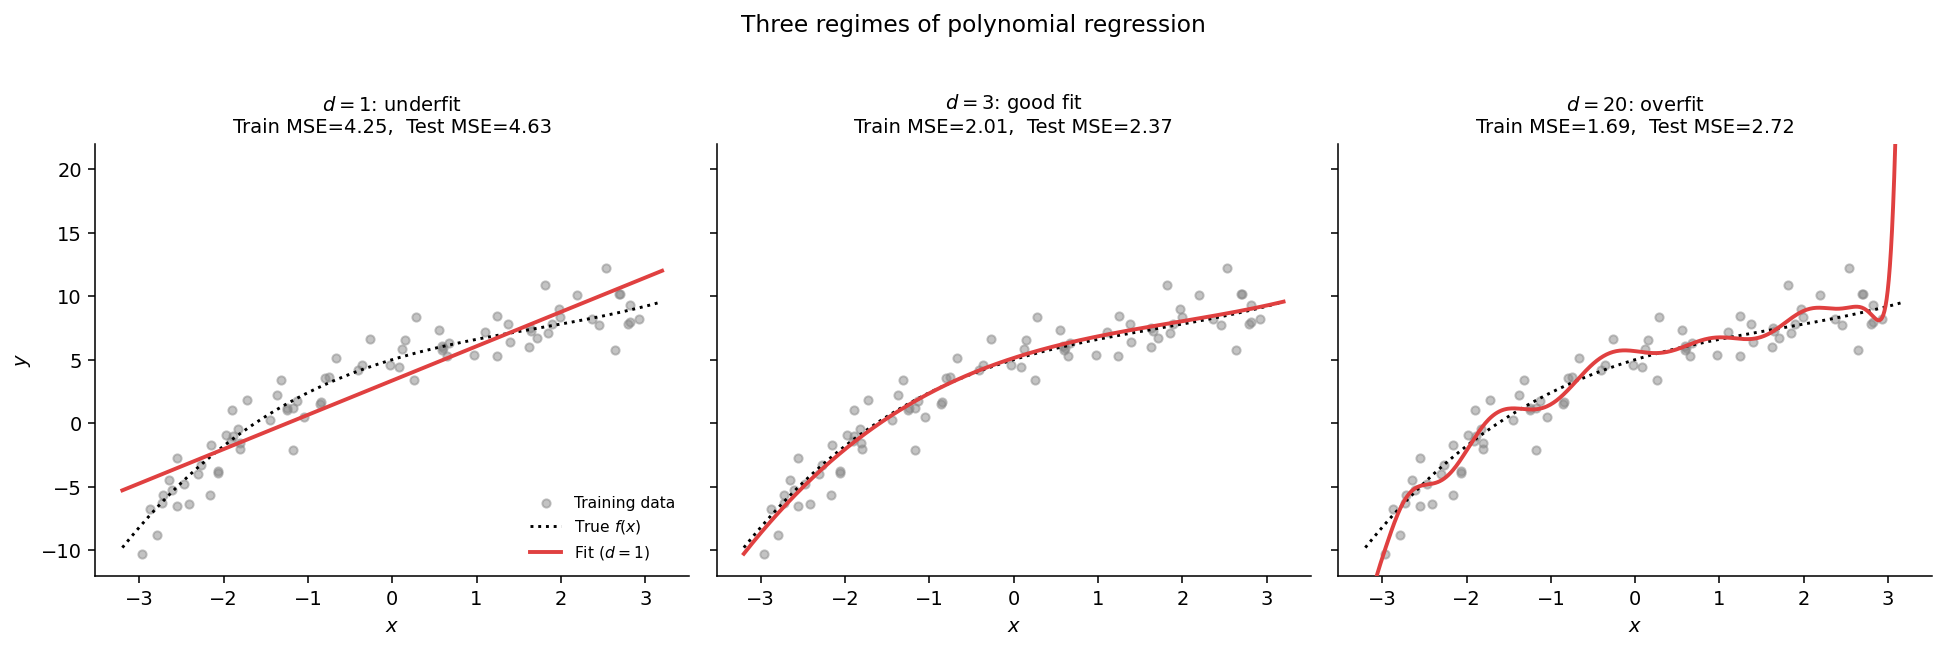

In [23]:
# --- Visualize the three regimes: fitted curves on one training set ---

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
fit_degrees = [1, 3, 15]
fit_labels  = ['$d=1$: underfit', '$d=3$: good fit', '$d=20$: overfit']

for ax, d, label in zip(axes, fit_degrees, fit_labels):
    ax.scatter(x_tr_s, y_tr_s, s=18, alpha=0.5, color=GRAY, zorder=1, label='Training data')
    ax.plot(x_plot, f_true(x_plot), color='black', linewidth=1.5,
            linestyle=':', label='True $f(x)$', zorder=2)

    m = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
    m.fit(x_tr_s.reshape(-1, 1), y_tr_s)
    y_fit = np.clip(m.predict(x_plot.reshape(-1, 1)), -20, 30)
    ax.plot(x_plot, y_fit, color=RED, linewidth=2, zorder=3, label=f'Fit ($d={d}$)')

    tr_mse = mean_squared_error(y_tr_s, m.predict(x_tr_s.reshape(-1, 1)))
    te_mse = mean_squared_error(y_te_s, m.predict(x_te_s.reshape(-1, 1)))
    ax.set_title(f'{label}\nTrain MSE={tr_mse:.2f},  Test MSE={te_mse:.2f}', fontsize=10)
    ax.set_xlabel('$x$')
    ax.set_ylim(-12, 22)
    if ax is axes[0]:
        ax.set_ylabel('$y$')
        ax.legend(frameon=False, fontsize=8, loc='lower right')

fig.suptitle('Three regimes of polynomial regression', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Learning curves

A **learning curve** plots train and test error as a function of training set size $n$ for a **fixed** model. They diagnose what is limiting performance:

| Pattern | Diagnosis | Fix |
|---|---|---|
| Both curves converge to a high value | High bias: model is fundamentally wrong | Increase complexity, add features |
| Large gap that shrinks slowly with $n$ | High variance: model is too flexible | Reduce complexity, regularize, get more data |
| Both curves converge to $\approx \sigma^2$ | Well specified | You're done! |

> **Practical use:** if a colleague says *"we need more data,"* a learning curve tells you whether adding data would actually help. If the model has high bias, more data will not help; you need a better model.

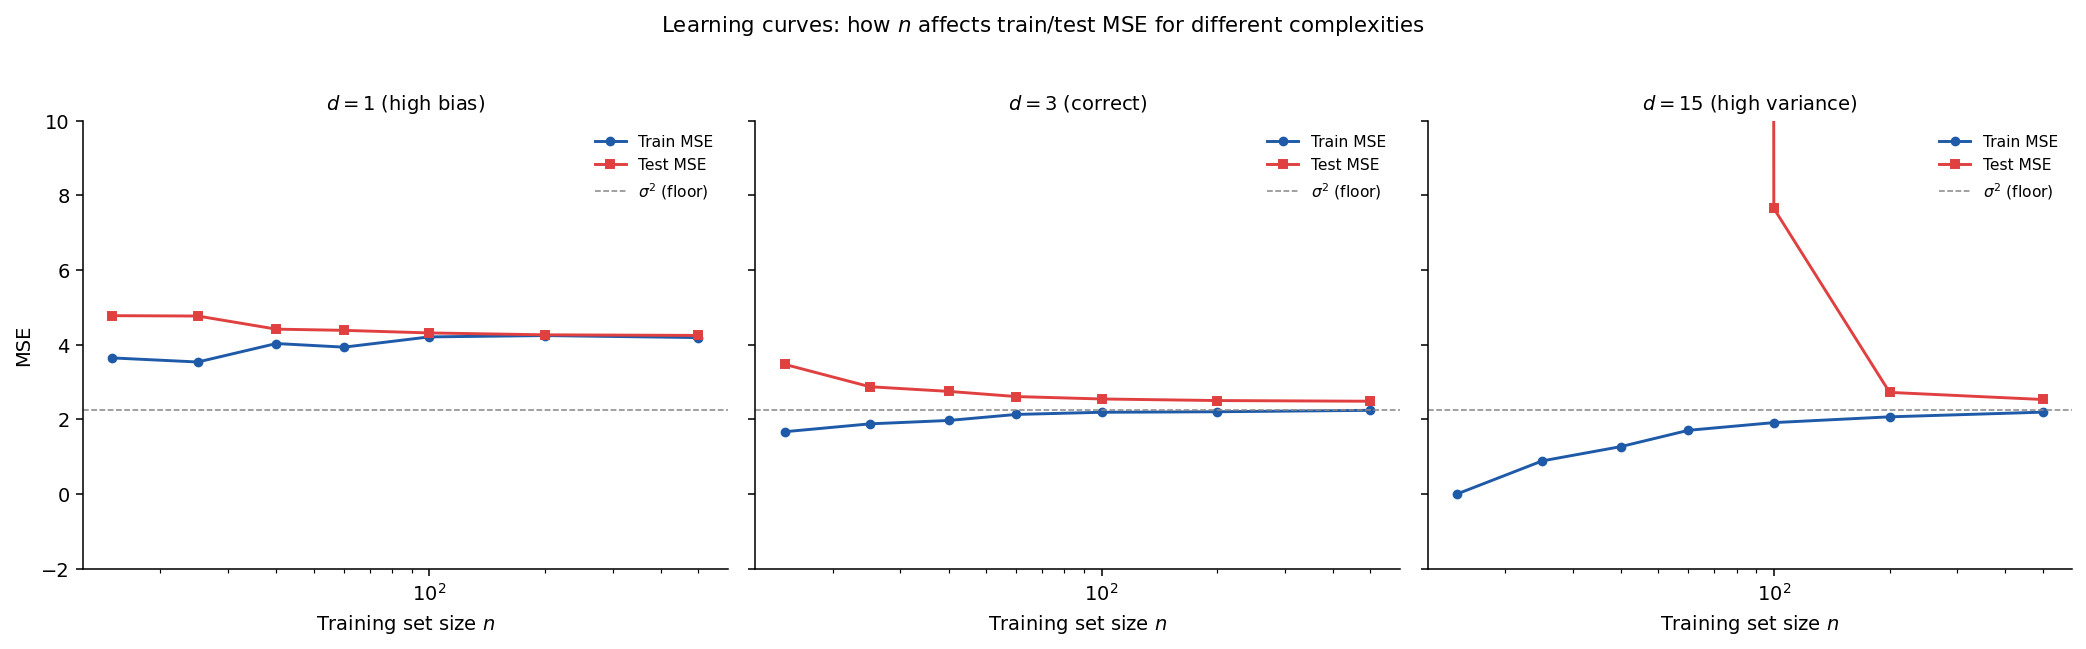

In [24]:
# --- Learning curves: train and test MSE vs. n for three model complexities ---

x_lc_te, y_lc_te = generate_data(1000, seed=777)  # fixed large test set
ns = [15, 25, 40, 60, 100, 200, 500]
lc_degrees = [1, 3, 15]
lc_labels  = ['$d=1$ (high bias)', '$d=3$ (correct)', '$d=15$ (high variance)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, d, lbl in zip(axes, lc_degrees, lc_labels):
    tr_errs, te_errs = [], []
    for n in ns:
        tr_runs, te_runs = [], []
        for rep in range(30):  # average over 30 draws to reduce Monte Carlo noise
            x_tr, y_tr = generate_data(n, seed=rep * 100 + n)
            m = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())
            m.fit(x_tr.reshape(-1, 1), y_tr)
            tr_runs.append(mean_squared_error(y_tr,    m.predict(x_tr.reshape(-1, 1))))
            te_runs.append(mean_squared_error(y_lc_te, m.predict(x_lc_te.reshape(-1, 1))))
        tr_errs.append(np.mean(tr_runs))
        te_errs.append(np.mean(te_runs))

    ax.plot(ns, tr_errs, 'o-', color=BLUE, label='Train MSE', markersize=4)
    ax.plot(ns, te_errs, 's-', color=RED,  label='Test MSE',  markersize=4)
    ax.axhline(SIGMA**2, color=GRAY, linestyle='--', linewidth=0.8, label='$\\sigma^2$ (floor)')
    ax.set_xlabel('Training set size $n$')
    ax.set_title(lbl, fontsize=10)
    ax.set_xscale('log')
    ax.set_ylim(-2, 10)
    ax.legend(frameon=False, fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel('MSE')

fig.suptitle('Learning curves: how $n$ affects train/test MSE for different complexities',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

**What to notice:**
- **$d=1$ (left):** Both curves converge quickly to a value well above $\sigma^2$. More data does not help — the model is too simple to fit the cubic pattern.
- **$d=3$ (center):** Both curves converge toward $\sigma^2$, the noise floor. This is the correctly specified model.
- **$d=15$ (right):** There is a large initial gap between train and test error. The gap closes slowly as $n$ increases because more data eventually constrains the 15 parameters. But even at $n=500$, test error is slightly above $d=3$.

---
## Block 4 · Train / Validation / Test Split

### Why one split is not enough

If you use the **test set** to choose among models (hyperparameters, architectures, degrees), the test set is no longer a fair estimate of generalization error. You have optimized against it, and the reported performance is too optimistic.

The solution is **three** non-overlapping sets:

| Set | Purpose | Touched how often? |
|---|---|---|
| **Training** | Fit model parameters $\hat{\theta}$ | Every training iteration |
| **Validation** | Choose hyperparameters $d^*, \alpha^*$ | Once per configuration |
| **Test** | Final, unbiased estimate of generalization error | **Exactly once** |

Formal requirement: $D_{\text{train}} \cap D_{\text{val}} = \emptyset$, $D_{\text{val}} \cap D_{\text{test}} = \emptyset$, $D_{\text{train}} \cap D_{\text{test}} = \emptyset$.

### Splitting strategies

| Strategy | When to use |
|---|---|
| **Random split** | i.i.d. data (80/10/10 or 60/20/20) |
| **Temporal split** | Time-series: train on past, validate on recent past, test on future. Random splitting leaks future information. |
| **Stratified split** | Imbalanced classes: preserves class proportions in each split |
| **Group split** | All observations from a group (user, station) go to the same split; otherwise the model memorizes group-specific patterns |

### The hold-out's weakness: variance of the estimate

A single train/val split gives *one* estimate of validation error. That estimate has variance $\text{Var}(\hat{R}_{\text{val}}) = \text{Var}(\ell) / n_{\text{val}}$. For small $n_{\text{val}}$, two different random splits can produce noticeably different model rankings. The solution: cross-validation.

In [25]:
# --- Load UCI Bike Sharing (hourly) ---
# If hour.csv is not present, download from UCI.
import os, zipfile, io

if os.path.exists('hour.csv'):
    bikes = pd.read_csv('hour.csv')
else:
    try:
        import urllib.request
        url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
        resp = urllib.request.urlopen(url, timeout=15)
        with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
            bikes = pd.read_csv(z.open('hour.csv'))
        print('Downloaded from UCI.')
    except Exception:
        # Fallback: minimal synthetic stand-in
        np.random.seed(0)
        n = 17379
        hr = np.arange(n) % 24
        mnth = ((np.arange(n) // (24 * 30)) % 12) + 1
        temp = np.clip(0.5 + 0.3*np.sin(2*np.pi*(mnth-1)/12) + 0.05*np.random.randn(n), 0, 1)
        cnt  = np.maximum(1, (80 + 150*temp + 60*np.sin(np.pi*hr/12)
                              + 20*np.random.randn(n))).astype(int)
        bikes = pd.DataFrame({'season': (mnth//3)+1, 'yr': np.arange(n)//(365*24),
                              'mnth': mnth, 'hr': hr, 'holiday': 0, 'weekday': np.arange(n)//24%7,
                              'workingday': (np.arange(n)//24%7 < 5).astype(int),
                              'weathersit': np.random.choice([1,2,3], n, p=[0.65,0.25,0.10]),
                              'temp': temp, 'atemp': np.clip(temp+0.02*np.random.randn(n),0,1),
                              'hum': np.clip(0.6+0.15*np.random.randn(n),0,1),
                              'windspeed': np.clip(0.2+0.1*np.random.randn(n),0,0.7),
                              'cnt': cnt})
        print('Using synthetic stand-in dataset.')

feature_cols = ['season','yr','mnth','hr','holiday','weekday',
                'workingday','weathersit','temp','atemp','hum','windspeed']
X_bike = bikes[feature_cols].values
y_bike  = bikes['cnt'].values

print(f'Bike sharing: n = {len(y_bike)}, p = {X_bike.shape[1]}')
print(f'Features: {feature_cols}')
bikes[feature_cols + ['cnt']].describe().round(2)

Downloaded from UCI.
Bike sharing: n = 17379, p = 12
Features: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.00,17379.0,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00
mean,2.50,0.5,6.54,11.55,0.03,3.00,0.68,1.43,0.50,0.48,0.63,0.19,189.46
std,1.11,0.5,3.44,6.91,0.17,2.01,0.47,0.64,0.19,0.17,0.19,0.12,181.39
min,1.00,0.0,1.00,0.00,0.00,0.00,0.00,1.00,0.02,0.00,0.00,0.00,1.00
25%,2.00,0.0,4.00,6.00,0.00,1.00,0.00,1.00,0.34,0.33,0.48,0.10,40.00
50%,3.00,1.0,7.00,12.00,0.00,3.00,1.00,1.00,0.50,0.48,0.63,0.19,142.00
75%,3.00,1.0,10.00,18.00,0.00,5.00,1.00,2.00,0.66,0.62,0.78,0.25,281.00
max,4.00,1.0,12.00,23.00,1.00,6.00,1.00,4.00,1.00,1.00,1.00,0.85,977.00


For reference: Var(cnt) = 32,900, std(cnt) = 181.4

  Seed    0: test MSE = 19,925   RMSE =  141.2   R^2 = 0.403
  Seed    7: test MSE = 20,490   RMSE =  143.1   R^2 = 0.373
  Seed   42: test MSE = 19,380   RMSE =  139.2   R^2 = 0.388
  Seed   99: test MSE = 19,804   RMSE =  140.7   R^2 = 0.387
  Seed 2024: test MSE = 20,056   RMSE =  141.6   R^2 = 0.381

  MSE  mean +/- std = 19,931 +/- 360
  RMSE mean         = 141.2 bikes/hour
  Coefficient of variation (MSE) = 1.81%


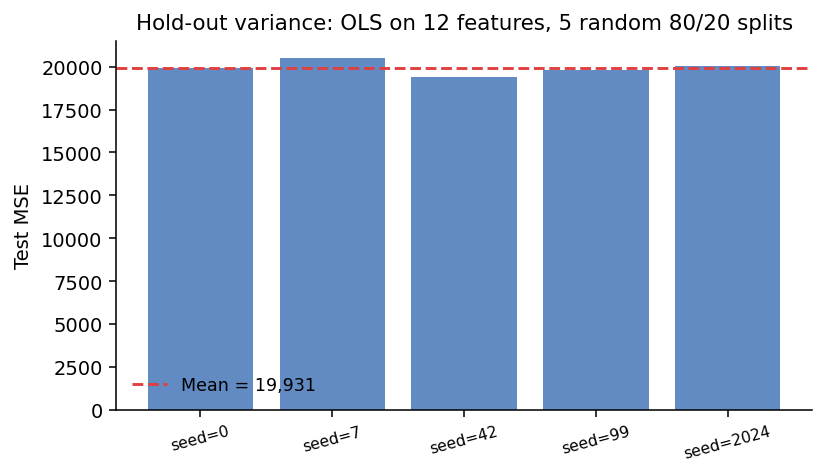

In [26]:
# --- Exercise: hold-out variance ---
# Split 80/20 five times with different random seeds.
# Fit OLS on all 12 features. How much does test MSE vary across splits?
#
# NOTE ON SCALE: `cnt` ranges from 1 to ~977 with std ~181, so its variance is
# ~33,000. An MSE in the thousands is therefore expected and NOT a sign of a bug.
# We report RMSE (same units as cnt) and R^2 alongside MSE so the numbers are
# interpretable.

print(f'For reference: Var(cnt) = {y_bike.var():,.0f}, std(cnt) = {y_bike.std():.1f}\n')

seeds = [0, 7, 42, 99, 2024]
holdout_mses, holdout_r2 = [], []

for s in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(X_bike, y_bike, test_size=0.2, random_state=s)
    lr = LinearRegression().fit(X_tr, y_tr)
    pred = lr.predict(X_te)
    mse = mean_squared_error(y_te, pred)
    holdout_mses.append(mse)
    holdout_r2.append(r2_score(y_te, pred))
    print(f'  Seed {s:4d}: test MSE = {mse:,.0f}   RMSE = {np.sqrt(mse):6.1f}   R^2 = {holdout_r2[-1]:.3f}')

print(f'\n  MSE  mean +/- std = {np.mean(holdout_mses):,.0f} +/- {np.std(holdout_mses):,.0f}')
print(f'  RMSE mean         = {np.sqrt(np.mean(holdout_mses)):.1f} bikes/hour')
print(f'  Coefficient of variation (MSE) = {np.std(holdout_mses)/np.mean(holdout_mses):.2%}')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([f'seed={s}' for s in seeds], holdout_mses, color=BLUE, alpha=0.7)
ax.axhline(np.mean(holdout_mses), color=RED, linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(holdout_mses):,.0f}')
ax.set_ylabel('Test MSE')
ax.set_title('Hold-out variance: OLS on 12 features, 5 random 80/20 splits')
ax.legend(frameon=False, fontsize=9)
plt.xticks(fontsize=8, rotation=15)
plt.tight_layout()
plt.show()

**Interpretation.** First, the *scale*: `cnt` (hourly bike rentals) ranges from 1 to roughly 977 with a standard deviation around 181, so its variance is about 33,000. A test MSE in the low thousands corresponds to an RMSE of roughly 140-150 bikes per hour, which is what a plain linear model with these 12 raw features achieves (R^2 around 0.39). 

What matters here is the *variation across splits*: the test MSE changes from one random 80/20 split to the next. If that standard deviation is large relative to the differences you are trying to detect between models, a single hold-out split is unreliable for model selection. This motivates cross-validation.

---
## Block 5 · Cross-Validation

### $K$-fold cross-validation

Partition the training data into $K$ disjoint folds $F_1, \ldots, F_K$. For each fold $k$: train on $D \setminus F_k$, evaluate on $F_k$:

$$\hat{R}_{\text{CV}} = \frac{1}{K} \sum_{k=1}^K \hat{R}_k, \qquad \hat{R}_k = \frac{1}{|F_k|}\sum_{i \in F_k} \ell(\hat{f}^{(-k)}(x_i), y_i)$$

**$K$ controls a bias-variance trade-off in the estimate itself:**

| $K$ | Training set per fold | Bias of estimate | Variance of estimate |
|---|---|---|---|
| Small ($K = 5$) | $0.8n$ | Higher (less data per fold) | Lower (less overlap) |
| Large ($K = n$, LOO) | $n - 1$ | Lower (nearly full data) | Higher (estimates are correlated) |

**$K = 5$ or $K = 10$ is standard.** For OLS there is a closed-form LOO formula: $e_{(-i)} = e_i / (1 - h_{ii})$ where $h_{ii}$ is the leverage (diagonal of the hat matrix $H = X(X^\top X)^{-1}X^\top$) | no refitting needed.

### Structured CV variants

Standard random $K$-fold assumes i.i.d. data. For structured data:

| Variant | Use case |
|---|---|
| **Time-series (walk-forward)** | Temporal data: train on $\{1,\ldots,t\}$, validate on $\{t+1,\ldots,t+h\}$, slide $t$ forward |
| **Group $K$-fold** | Groups (stations, users) never split across folds |
| **Stratified $K$-fold** | Imbalanced classification: preserves class proportions in each fold |

Method                          Mean MSE     Std MSE        RMSE
----------------------------------------------------------------
Random 5-fold                     20,136         561       141.9
Time-series walk-forward          25,356       8,142       159.2

Time-series CV is 25.9% higher MSE than random CV -- random CV is overoptimistic.


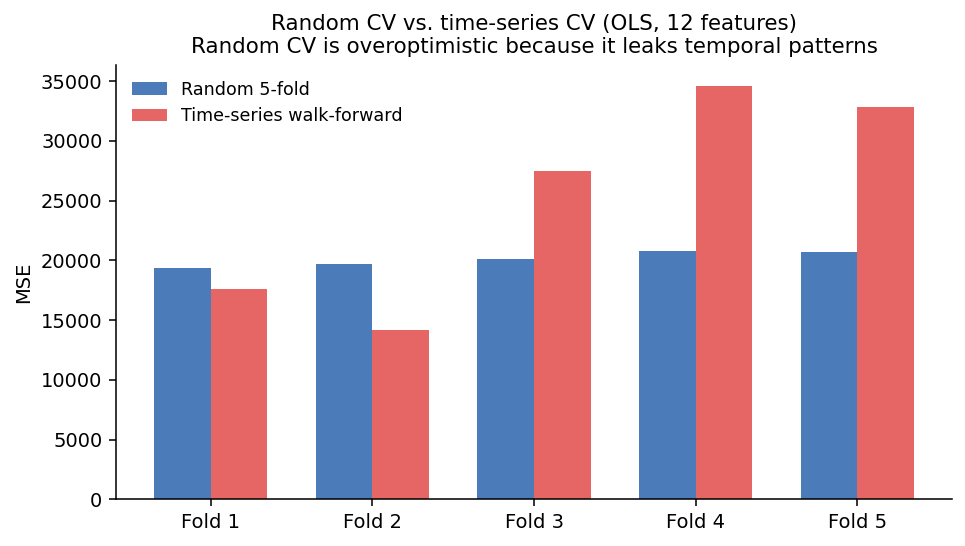

In [27]:
# --- Compare random 5-fold CV vs. time-series walk-forward CV ---
# Both use OLS on all 12 features.
# Random CV leaks temporal information -> overoptimistic error estimate.
#
# As in the hold-out exercise, MSE is in (bikes/hour)^2, so values in the
# thousands are expected given std(cnt) ~ 181. We also print RMSE.

lr_pipe = LinearRegression()

# Random 5-fold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
scores_random = -cross_val_score(lr_pipe, X_bike, y_bike,
                                  cv=kf, scoring='neg_mean_squared_error')

# Time-series walk-forward
tscv = TimeSeriesSplit(n_splits=5)
scores_ts = -cross_val_score(lr_pipe, X_bike, y_bike,
                              cv=tscv, scoring='neg_mean_squared_error')

print('%-28s  %10s  %10s  %10s' % ('Method', 'Mean MSE', 'Std MSE', 'RMSE'))
print('-' * 64)
print('%-28s  %10s  %10s  %10s' % ('Random 5-fold',
      f'{scores_random.mean():>10,.0f}', f'{scores_random.std():>10,.0f}',
      f'{np.sqrt(scores_random.mean()):>10.1f}'))
print('%-28s  %10s  %10s  %10s' % ('Time-series walk-forward',
      f'{scores_ts.mean():>10,.0f}', f'{scores_ts.std():>10,.0f}',
      f'{np.sqrt(scores_ts.mean()):>10.1f}'))
print(f'\nTime-series CV is {(scores_ts.mean() - scores_random.mean())/scores_random.mean():.1%} '
      f'higher MSE than random CV -- random CV is overoptimistic.')

fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(5)
w = 0.35
ax.bar(x_pos - w/2, scores_random, w, label='Random 5-fold',           color=BLUE, alpha=0.8)
ax.bar(x_pos + w/2, scores_ts,     w, label='Time-series walk-forward', color=RED,  alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylabel('MSE')
ax.set_title('Random CV vs. time-series CV (OLS, 12 features)\nRandom CV is overoptimistic because it leaks temporal patterns')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Why does this matter?** Random CV shuffles the data, so a model trained on Tuesday can be evaluated on Monday; it sees "future" patterns during training. Walk-forward CV enforces that the model always trains on the past and predicts the future, matching the deployment scenario.

---
## Block 6 · Hyperparameter Tuning via Validation

### Parameters vs. hyperparameters

| | **Parameters** $\theta$ | **Hyperparameters** $\lambda$ |
|---|---|---|
| What they are | Learned by optimization on training data | Set before training; control the learning process |
| Examples | Regression coefficients $\beta$, NN weights | Polynomial degree $d$, regularization strength $\alpha$, $k$ in $k$-NN |
| How chosen | $\hat{\theta} = \arg\min_\theta \hat{R}_{\text{train}}(\theta)$ | By validation error — training error always prefers the most complex model |

### Grid search

Define a grid over the hyperparameter space and evaluate each combination:
$$\lambda^* = \arg\min_{\lambda \in \text{grid}} \hat{R}_{\text{CV}}(\lambda)$$

Cost grows exponentially: $|G_1| \times |G_2| \times \ldots$ configurations, each requiring a full CV run.

### Random search

Bergstra and Bengio (2012) showed that **random search is more efficient than grid search** when some hyperparameters matter more than others. In a 2D grid with $m$ points per axis, you see only $m$ distinct values per dimension. With $m^2$ random points, you see $m^2$ distinct values per dimension — much better coverage of the important dimension.

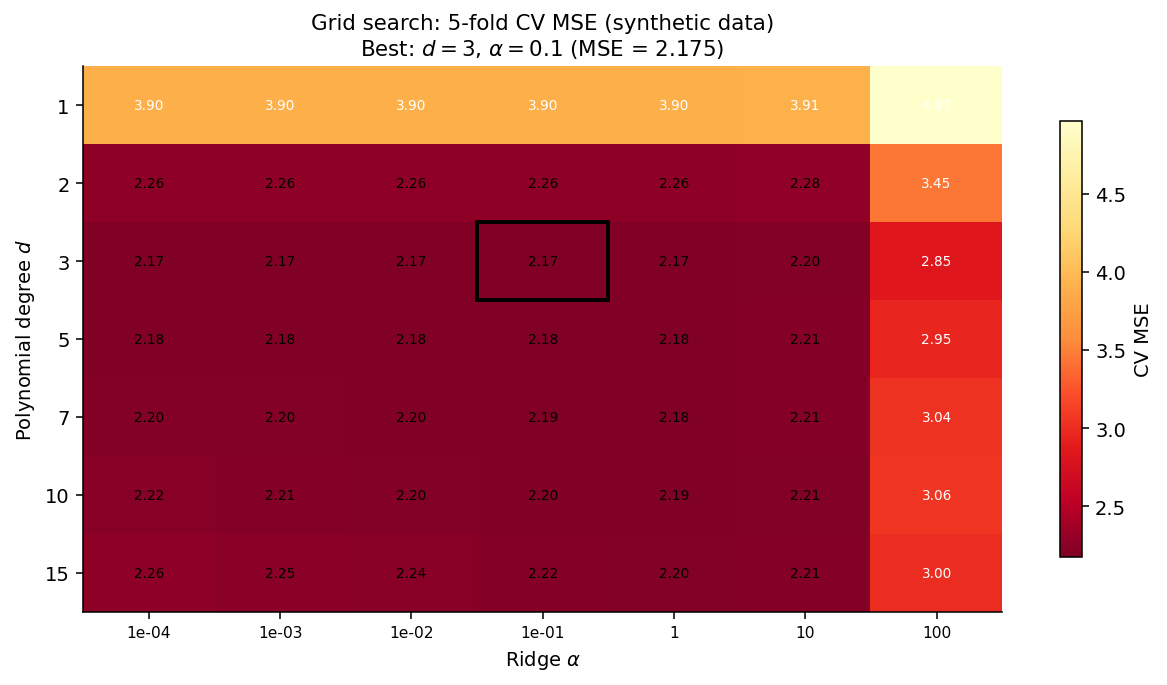

Best hyperparameters: degree=3, alpha=0.1


In [28]:
# --- Grid search: polynomial degree x Ridge alpha on synthetic data ---
# Using synthetic data for pedagogical clarity (clean U-shape).

x_cv_full, y_cv_full = generate_data(400, seed=123)

degrees_grid = [1, 2, 3, 5, 7, 10, 15]
alphas_grid  = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
kf5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = np.zeros((len(degrees_grid), len(alphas_grid)))
for i, d in enumerate(degrees_grid):
    for j, alpha in enumerate(alphas_grid):
        pipe = make_pipeline(PolynomialFeatures(d, include_bias=False),
                             StandardScaler(), Ridge(alpha=alpha))
        scores = -cross_val_score(pipe, x_cv_full.reshape(-1, 1), y_cv_full,
                                  cv=kf5, scoring='neg_mean_squared_error')
        cv_results[i, j] = scores.mean()

best_idx = np.unravel_index(cv_results.argmin(), cv_results.shape)
best_d     = degrees_grid[best_idx[0]]
best_alpha = alphas_grid[best_idx[1]]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(cv_results, cmap='YlOrRd_r', aspect='auto')
ax.set_xticks(range(len(alphas_grid)))
ax.set_xticklabels([f'{a:.0e}' if a < 1 else f'{a:.0f}' for a in alphas_grid], fontsize=8)
ax.set_yticks(range(len(degrees_grid)))
ax.set_yticklabels(degrees_grid)
ax.set_xlabel('Ridge $\\alpha$')
ax.set_ylabel('Polynomial degree $d$')
ax.set_title(f'Grid search: 5-fold CV MSE (synthetic data)\nBest: $d={best_d}$, $\\alpha={best_alpha}$ '
             f'(MSE = {cv_results[best_idx]:.3f})')
for i in range(len(degrees_grid)):
    for j in range(len(alphas_grid)):
        col = 'white' if cv_results[i, j] > cv_results.mean() else 'black'
        ax.text(j, i, f'{cv_results[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color=col)
ax.add_patch(plt.Rectangle((best_idx[1]-0.5, best_idx[0]-0.5), 1, 1,
                            fill=False, edgecolor='black', linewidth=2))
fig.colorbar(im, ax=ax, shrink=0.8, label='CV MSE')
plt.tight_layout()
plt.show()
print(f'Best hyperparameters: degree={best_d}, alpha={best_alpha}')

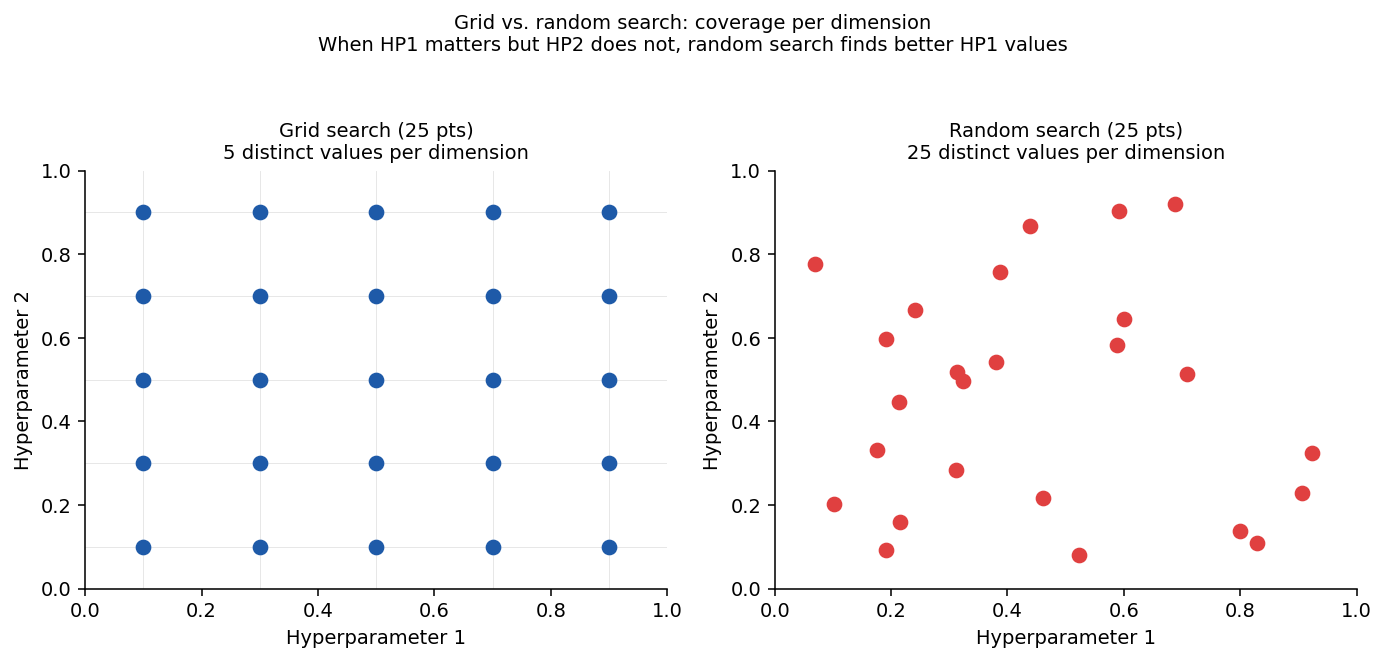

In [29]:
# --- Visual: grid search vs. random search coverage ---
# With the same budget of 25 evaluations, random search covers many more
# distinct values per dimension than grid search.

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Grid: 5x5
g1 = np.linspace(0.1, 0.9, 5)
gx, gy = np.meshgrid(g1, g1)
axes[0].scatter(gx.ravel(), gy.ravel(), s=50, color=BLUE, zorder=3)
for v in g1:
    axes[0].axvline(v, color=GRAY, alpha=0.2, linewidth=0.5)
    axes[0].axhline(v, color=GRAY, alpha=0.2, linewidth=0.5)
axes[0].set_title('Grid search (25 pts)\n5 distinct values per dimension', fontsize=10)
axes[0].set_xlabel('Hyperparameter 1')
axes[0].set_ylabel('Hyperparameter 2')

# Random: 25
rx = rng.uniform(0.05, 0.95, 25)
ry = rng.uniform(0.05, 0.95, 25)
axes[1].scatter(rx, ry, s=50, color=RED, zorder=3)
axes[1].set_title('Random search (25 pts)\n25 distinct values per dimension', fontsize=10)
axes[1].set_xlabel('Hyperparameter 1')
axes[1].set_ylabel('Hyperparameter 2')

for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle('Grid vs. random search: coverage per dimension\n'
             'When HP1 matters but HP2 does not, random search finds better HP1 values',
             fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

---
## Block 7 · Regularization

### Why constrain the model?

Regularization adds a penalty on model complexity to the training objective:
$$\hat{\theta}_{\text{reg}} = \arg\min_\theta \left[\frac{1}{n}\sum_{i=1}^n \ell(f_\theta(x_i), y_i) + \alpha \cdot \Omega(\theta)\right]$$

Increasing $\alpha$ **increases bias** (the model is more constrained) and **decreases variance** (less sensitive to the training set). This is the bias-variance trade-off implemented as an optimization penalty.

### Ridge regression ($L_2$)

$$\hat{\beta}_{\text{ridge}} = \arg\min_\beta \left[\|y - X\beta\|_2^2 + \alpha\|\beta\|_2^2\right] = (X^\top X + \alpha I)^{-1} X^\top y$$

OLS can fail when $X^\top X$ is nearly singular (correlated columns). Ridge adds $\alpha I$ to the diagonal, inflating all eigenvalues. Coefficients **shrink toward zero** but never reach exactly zero.

Compared to OLS: $\text{Bias}^2_{\text{ridge}} > 0$ but $\text{Var}_{\text{ridge}} < \text{Var}_{\text{OLS}}$. There always exists $\alpha > 0$ such that $\text{EPE}_{\text{ridge}} < \text{EPE}_{\text{OLS}}$.

### Lasso ($L_1$) and elastic net

$$\hat{\beta}_{\text{lasso}} = \arg\min_\beta \left[\|y - X\beta\|_2^2 + \alpha\|\beta\|_1\right]$$

The $L_1$ penalty produces **sparse** solutions. Some coefficients are driven to *exactly* zero, performing automatic feature selection. Why? The $L_1$ constraint set $\{\beta : \|\beta\|_1 \leq t\}$ is a diamond with corners on the coordinate axes. The OLS contour ellipses are more likely to touch a corner (where some $\beta_j = 0$) than the smooth $L_2$ ball.

**Elastic net** combines both: $\Omega(\beta) = \alpha[\rho\|\beta\|_1 + (1-\rho)\|\beta\|_2^2]$. Useful when features are correlated. Lasso arbitrarily selects one from a correlated group, while elastic net includes the group.

### Bayesian interpretation

Regularization is equivalent to putting a **prior** on the parameters:
- **Ridge** = Gaussian prior: $\beta_j \sim N(0, 1/\alpha)$
- **Lasso** = Laplace prior: $\beta_j \sim \text{Laplace}(0, 1/\alpha)$

The regularized estimator is the **MAP** (maximum a posteriori) estimate under the corresponding prior. The Laplace prior has a sharp peak at zero; that is why it encourages sparsity.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.041e+01, tolerance: 2.278e-01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.671e+01, tolerance: 2.278e-01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

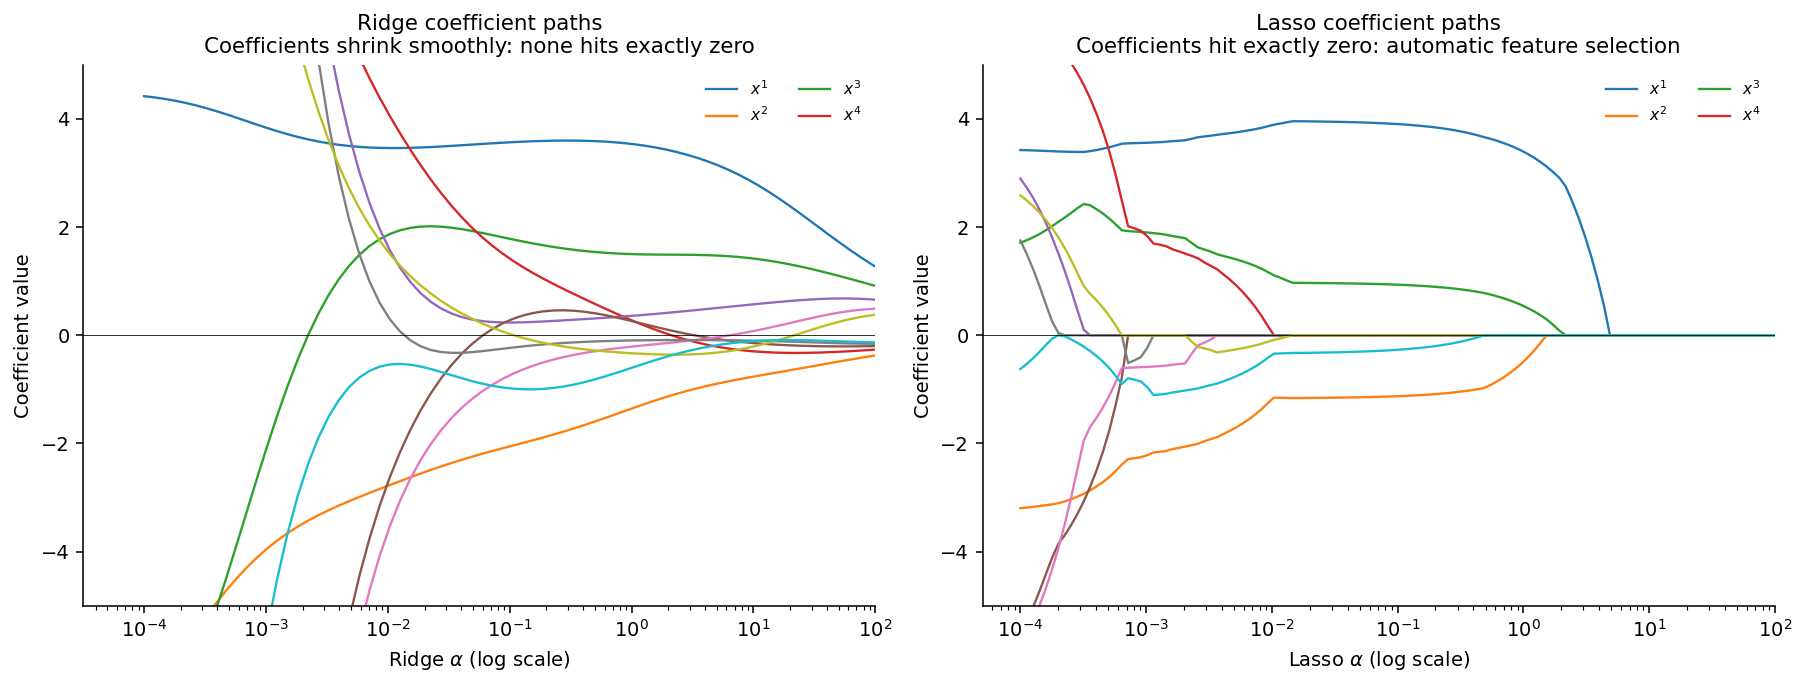

In [30]:
# --- Ridge and Lasso coefficient paths on degree-10 polynomial (synthetic data) ---

poly10 = PolynomialFeatures(10, include_bias=False)
X_p10  = poly10.fit_transform(x_tr_s.reshape(-1, 1))
sc10   = StandardScaler()
X_p10_sc = sc10.fit_transform(X_p10)

alphas_path = np.logspace(-4, 6, 120)

ridge_coefs = np.array([Ridge(alpha=a).fit(X_p10_sc, y_tr_s).coef_
                         for a in alphas_path])

alphas_lasso = np.logspace(-4, 2, 120)
lasso_coefs  = np.array([Lasso(alpha=a, max_iter=10000).fit(X_p10_sc, y_tr_s).coef_
                          for a in alphas_lasso])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for j in range(ridge_coefs.shape[1]):
    axes[0].plot(alphas_path, ridge_coefs[:, j], linewidth=1.2,
                 label=f'$x^{j+1}$' if j < 4 else None)
axes[0].set_xscale('log')
axes[0].axhline(0, color='black', linewidth=0.4)
axes[0].set_ylim(-5, 5)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel('Ridge $\\alpha$ (log scale)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge coefficient paths\nCoefficients shrink smoothly: none hits exactly zero')
axes[0].legend(frameon=False, fontsize=8, ncol=2)

for j in range(lasso_coefs.shape[1]):
    axes[1].plot(alphas_lasso, lasso_coefs[:, j], linewidth=1.2,
                 label=f'$x^{j+1}$' if j < 4 else None)
axes[1].set_xscale('log')
axes[1].axhline(0, color='black', linewidth=0.4)
axes[1].set_ylim(-5, 5)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Lasso $\\alpha$ (log scale)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Lasso coefficient paths\nCoefficients hit exactly zero: automatic feature selection')
axes[1].legend(frameon=False, fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

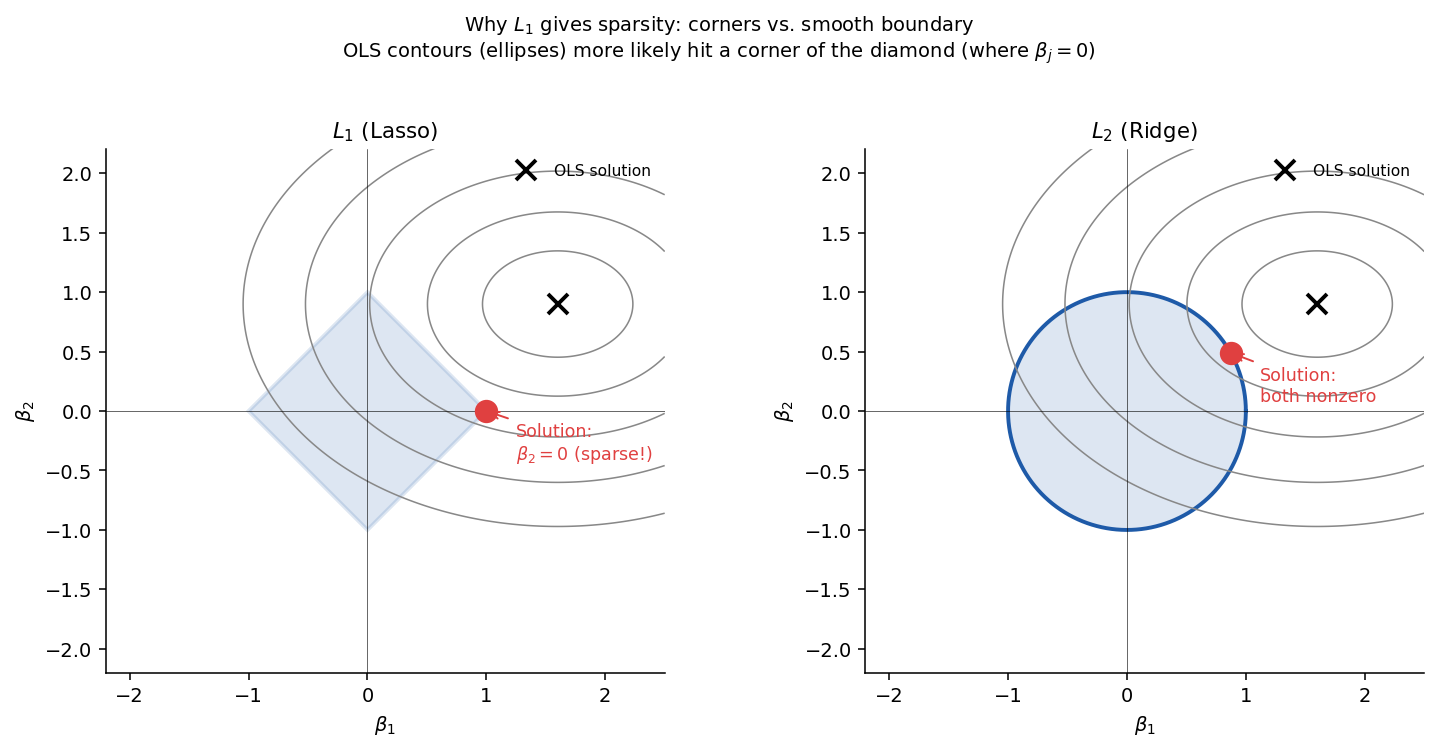

In [31]:
# --- L1 vs. L2 constraint geometry: why L1 gives sparsity ---

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
B1g = np.linspace(-2.5, 2.5, 300)
B2g = np.linspace(-2.5, 2.5, 300)
B1, B2 = np.meshgrid(B1g, B2g)
OLS_center = (1.6, 0.9)  # OLS solution (unconstrained)
Z = (B1 - OLS_center[0])**2 + 2*(B2 - OLS_center[1])**2  # loss contours

for ax, title, is_l1 in zip(axes, ['$L_1$ (Lasso)', '$L_2$ (Ridge)'], [True, False]):
    t = 1.0
    if is_l1:
        diamond = plt.Polygon([(t,0),(0,t),(-t,0),(0,-t)],
                              facecolor=BLUE, alpha=0.15, edgecolor=BLUE, linewidth=2)
        ax.add_patch(diamond)
        ax.plot(t, 0, 'o', color=RED, markersize=11, zorder=5)
        ax.annotate('Solution:\n$\\beta_2 = 0$ (sparse!)',
                    (t, 0), textcoords='offset points', xytext=(15, -25),
                    fontsize=9, color=RED,
                    arrowprops=dict(arrowstyle='->', color=RED))
    else:
        theta_c = np.linspace(0, 2*np.pi, 300)
        ax.fill(t*np.cos(theta_c), t*np.sin(theta_c), facecolor=BLUE, alpha=0.15)
        ax.plot(t*np.cos(theta_c), t*np.sin(theta_c), color=BLUE, linewidth=2)
        sol_angle = np.arctan2(OLS_center[1], OLS_center[0])
        sol_pt = (t*np.cos(sol_angle), t*np.sin(sol_angle))
        ax.plot(*sol_pt, 'o', color=RED, markersize=11, zorder=5)
        ax.annotate('Solution:\nboth nonzero',
                    sol_pt, textcoords='offset points', xytext=(15, -25),
                    fontsize=9, color=RED,
                    arrowprops=dict(arrowstyle='->', color=RED))

    ax.contour(B1, B2, Z, levels=[0.4, 1.2, 2.5, 4.5, 7], colors=GRAY,
               linewidths=0.8, linestyles='-')
    ax.plot(*OLS_center, 'x', color='black', markersize=10,
            markeredgewidth=2, label='OLS solution', zorder=5)
    ax.set_xlim(-2.2, 2.5); ax.set_ylim(-2.2, 2.2)
    ax.set_xlabel('$\\beta_1$'); ax.set_ylabel('$\\beta_2$')
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.axhline(0, color='black', linewidth=0.3)
    ax.axvline(0, color='black', linewidth=0.3)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Why $L_1$ gives sparsity: corners vs. smooth boundary\n'
             'OLS contours (ellipses) more likely hit a corner of the diamond (where $\\beta_j=0$)',
             fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

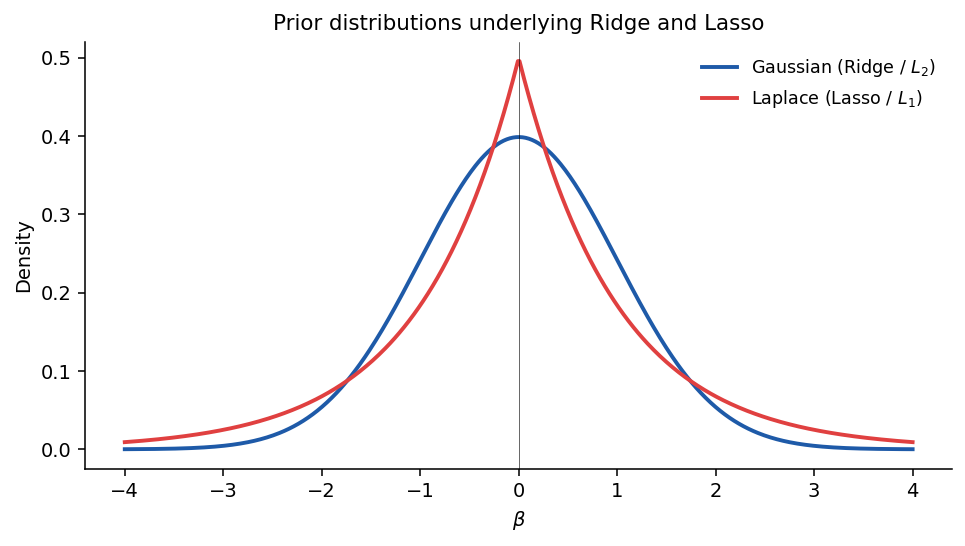

In [32]:
# --- Bayesian interpretation: Gaussian vs. Laplace prior ---
from scipy.stats import norm as sp_norm, laplace as sp_laplace

x_prior = np.linspace(-4, 4, 500)
scale = 1.0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_prior, sp_norm.pdf(x_prior, 0, scale),    color=BLUE, linewidth=2,
        label='Gaussian (Ridge / $L_2$)')
ax.plot(x_prior, sp_laplace.pdf(x_prior, 0, scale), color=RED,  linewidth=2,
        label='Laplace (Lasso / $L_1$)')
ax.axvline(0, color='black', linewidth=0.3)
ax.set_xlabel('$\\beta$')
ax.set_ylabel('Density')
ax.set_title('Prior distributions underlying Ridge and Lasso')
ax.legend(frameon=False, fontsize=9)
# ax.annotate('Laplace has sharper peak at 0\n→ encourages sparsity',
#             (0, sp_laplace.pdf(0, 0, scale)),
#             textcoords='offset points', xytext=(80, -15),
#             fontsize=9, color=RED,
#             arrowprops=dict(arrowstyle='->', color=RED))
plt.tight_layout()
plt.show()

In [ ]:
# --- OLS vs. Ridge (CV-tuned) vs. Lasso (CV-tuned) on Bike Sharing ---
# Temporal split: first 70% train, last 30% test.
#
# Regularization only helps when the unregularized model is
# high-variance. With just 12 well-conditioned, low-collinearity features and
# ~12,000 training rows, plain OLS barely overfits, so Ridge/Lasso have nothing
# to buy back and they collapse onto OLS (near-identical MSE).
#
# To make the bias-variance trade-off visible, we build a rich, high-dimensional
# feature space: one-hot encode the categorical/cyclical variables (hour, month,
# weekday, season, weather) and add pairwise interactions, expanding to >1000
# features. OLS now has enough flexibility to overfit.
#
# NOTE: one-hot dummies plus their interactions are linearly
# dependent (e.g. workingday is a function of weekday/holiday). The raw expanded
# matrix is therefore RANK-DEFICIENT, and unregularized OLS on it explodes
# (coefficients ~1e14, meaningless test error). We prune the design to a
# full-rank, well-conditioned subset using a pivoted QR factorization. This
# drops the redundant columns and is itself a clean illustration of detecting
# and removing collinear features.

from scipy.linalg import qr

cat_cols = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
num_cols = ['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed']

encoder = ColumnTransformer([
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
    ('num', 'passthrough', num_cols),
])
X_enc  = encoder.fit_transform(bikes)
X_full = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_enc)

n_split = int(0.7 * len(y_bike))
y_tr_r, y_te_r = y_bike[:n_split], y_bike[n_split:]

# Standardize on the training rows, then keep only independent columns.
sc = StandardScaler()
X_tr_full = sc.fit_transform(X_full[:n_split])
X_te_full = sc.transform(X_full[n_split:])

def full_rank_columns(Xs, rtol=1e-8):
    """Indices of linearly independent columns, via pivoted QR."""
    _, R, piv = qr(Xs, mode='economic', pivoting=True)
    d = np.abs(np.diag(R))
    keep = piv[d > rtol * d[0]]
    return np.sort(keep)

keep = full_rank_columns(X_tr_full)
X_tr_sc = X_tr_full[:, keep]
X_te_sc = X_te_full[:, keep]
print(f'Expanded feature space: {X_full.shape[1]} columns '
      f'-> {len(keep)} kept after dropping collinear ones '
      f'(condition number {np.linalg.cond(X_tr_sc):.1e}).\n')

ols   = LinearRegression().fit(X_tr_sc, y_tr_r)
ridge = RidgeCV(alphas=np.logspace(-1, 5, 60)).fit(X_tr_sc, y_tr_r)
# max_iter raised and tol relaxed so coordinate descent converges
# (avoids ConvergenceWarning on this wide, correlated design).
lasso = LassoCV(alphas=np.logspace(-2, 4, 40), max_iter=50000, tol=1e-3, cv=5).fit(X_tr_sc, y_tr_r)

def report(model):
    pred = model.predict(X_te_sc)
    return mean_squared_error(y_te_r, pred), r2_score(y_te_r, pred)

mse_ols,   r2_ols   = report(ols)
mse_ridge, r2_ridge = report(ridge)
mse_lasso, r2_lasso = report(lasso)

print('%-25s  %10s  %8s  %12s' % ('Model', 'Test MSE', 'R^2', 'Best alpha'))
print('-' * 60)
print('%-25s  %10s  %8.3f  %12s' % ('OLS (no penalty)', f'{mse_ols:>10,.0f}',   r2_ols,   '--'))
print('%-25s  %10s  %8.3f  %12s' % ('Ridge (CV-tuned)', f'{mse_ridge:>10,.0f}', r2_ridge, f'{ridge.alpha_:>12.2f}'))
print('%-25s  %10s  %8.3f  %12s' % ('Lasso (CV-tuned)', f'{mse_lasso:>10,.0f}', r2_lasso, f'{lasso.alpha_:>12.4f}'))
n_zero = int(np.sum(np.abs(lasso.coef_) < 1e-8))
print(f'\nLasso set {n_zero} of {len(lasso.coef_)} coefficients to exactly zero '
      f'({n_zero/len(lasso.coef_):.0%} of the (pruned) feature space).')

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: test MSE -- all finite and comparable on a linear axis.
methods = ['OLS', 'Ridge', 'Lasso']
mses    = [mse_ols, mse_ridge, mse_lasso]
colors  = [GRAY, BLUE, RED]
axes[0].bar(methods, mses, color=colors, alpha=0.85)
axes[0].set_ylabel('Test MSE')
axes[0].set_title(f'OLS vs. Ridge vs. Lasso\n(rich feature space, p={len(keep)}, temporal split)')
axes[0].set_ylim(0, max(mses) * 1.15)
for i, v in enumerate(mses):
    axes[0].text(i, v + max(mses)*0.02, f'{v:,.0f}', ha='center', fontsize=9)

# Right: coefficient magnitudes. Now all coefficients are O(10), so a simple
# linear histogram is readable. Bars show Ridge shrinking everything toward 0
# and Lasso piling many coefficients at exactly 0.
axes[1].hist(ols.coef_,   bins=40, alpha=0.55, color=GRAY, label='OLS')
axes[1].hist(ridge.coef_, bins=40, alpha=0.55, color=BLUE, label='Ridge')
axes[1].hist(lasso.coef_, bins=40, alpha=0.65, color=RED,  label='Lasso')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_xlabel('Coefficient value (standardized features)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Coefficient distribution\nRidge shrinks all; Lasso piles many at exactly 0')
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

Expanded feature space: 1484 columns -> 955 kept after dropping collinear ones (condition number 3.0e+03).



---
## Summary

| Block | Key idea | Practical takeaway |
|---|---|---|
| **1. Generalization** | The goal is test performance, not training performance | Training error always decreases with complexity; test error does not |
| **2. Decomposition** | $\text{EPE} = \sigma^2 + \text{Bias}^2 + \text{Var}$ | Memorize and use this equation |
| **3. Under/Overfit** | High bias = both errors high. High variance = big train/test gap | Diagnose with learning curves and fitted-curve plots |
| **4. Three sets** | Train fits parameters. Validation selects hyperparameters. Test evaluates, once. | Never look at test until the final evaluation |
| **5. Cross-validation** | $K$-fold reduces the variance of your generalization estimate | Use nested CV when both selecting and evaluating; use time-series CV for temporal data |
| **6. Tuning** | Hyperparameters cannot be chosen by training error | Grid search is simple; random search is more efficient when not all HPs matter equally |
| **7. Regularization** | Trades bias for variance reduction | $L_2$ = Ridge (shrinks, no zeros). $L_1$ = Lasso (sparsity). Penalty strength is a hyperparameter. Regularization = prior (Bayesian lens). |

### References

- Geman, S., Bienenstock, E., and Doursat, R. (1992). Neural Networks and the Bias/Variance Dilemma. *Neural Computation*, 4(1).
- Hastie, T., Tibshirani, R., and Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Chapters 2, 7.
- Hoerl, A. E., and Kennard, R. W. (1970). Ridge Regression. *Technometrics*, 12(1).
- Tibshirani, R. (1996). Regression Shrinkage and Selection via the Lasso. *JRSS-B*, 58(1).
- Bergstra, J., and Bengio, Y. (2012). Random Search for Hyper-Parameter Optimization. *JMLR*, 13.
- Belkin, M., et al. (2019). Reconciling modern machine-learning practice and the classical bias-variance trade-off. *PNAS*, 116(32).
- Fanaee-T, H., and Gama, J. (2014). Event labeling combining ensemble detectors and background knowledge. *Progress in AI*, 2.